In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
df = pd.read_csv("../data/processed/az-628_expression_response.csv")

feature_pipeline = joblib.load("../models/feature_pipeline.pkl")
best_rf = joblib.load("../models/az-628_best_rf.pkl")
best_xgb = joblib.load("../models/az-628_best_xgb.pkl")

In [3]:
non_gene_cols = [
    'IDs', 'Drug.Name', 'ModelID', 'Response',
    'screen', 'dose', 'repurposing_target', 'MOA', 'Synonyms'
]

X = df.drop(columns=[col for col in non_gene_cols if col in df.columns])
X = X.select_dtypes(include='number')
y = df['Response']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

X_train_processed = feature_pipeline.transform(X_train)
X_test_processed = feature_pipeline.transform(X_test)

In [4]:
def evaluate_saved_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    return y_pred, {
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

In [5]:
rf_pred, rf_results = evaluate_saved_model(
    "Tuned Random Forest",
    best_rf,
    X_test_processed,
    y_test
)

xgb_pred, xgb_results = evaluate_saved_model(
    "Tuned XGBoost",
    best_xgb,
    X_test_processed,
    y_test
)

final_results = pd.DataFrame([rf_results, xgb_results])
final_results
print(f"Response Range: {(y.max() - y.min()):.3f}")

Response Range: 9.066


In [6]:
all_results = pd.DataFrame([
    {"Model": "Ridge", "RMSE": 0.985170, "R2": 0.423995},
    {"Model": "Random Forest", "RMSE": 0.896162, "R2": 0.523376},
    {"Model": "XGBoost", "RMSE": 0.952983, "R2": 0.461018},
    {"Model": "SVR", "RMSE": 0.953204, "R2": 0.460769},
    {"Model": "Tuned Random Forest", "RMSE": 0.892632, "R2": 0.527123},
    {"Model": "Tuned XGBoost", "RMSE": 0.883107, "R2": 0.537161}
])

all_results.sort_values("RMSE")

,Model,RMSE,R2
5,Tuned XGBoost,0.883107,0.537161
4,Tuned Random Forest,0.892632,0.527123
1,Random Forest,0.896162,0.523376
2,XGBoost,0.952983,0.461018
3,SVR,0.953204,0.460769
0,Ridge,0.985170,0.423995


In [7]:
all_results.to_csv("../models/az-628_final_results.csv", index=False)

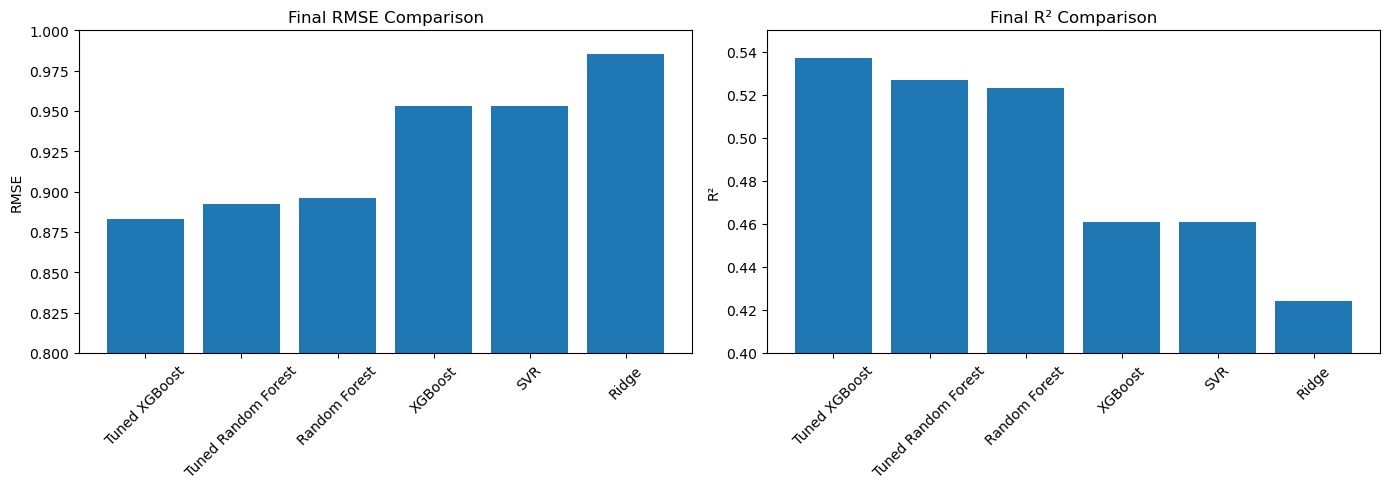

In [8]:
results_sorted = all_results.sort_values("RMSE")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(results_sorted["Model"], results_sorted["RMSE"])
axes[0].set_ylabel("RMSE")
axes[0].set_title("Final RMSE Comparison")
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_ylim([0.8, 1])

axes[1].bar(results_sorted["Model"], results_sorted["R2"])
axes[1].set_ylabel("R²")
axes[1].set_title("Final R² Comparison")
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_ylim([0.4, 0.55])

plt.tight_layout()
plt.show()

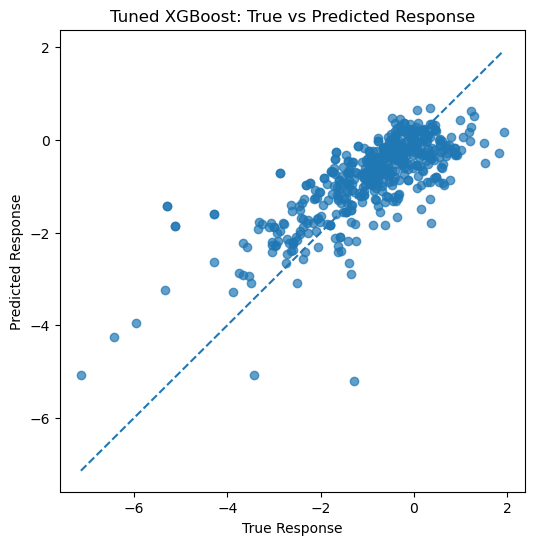

In [9]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, xgb_pred, alpha=0.7)
plt.xlabel("True Response")
plt.ylabel("Predicted Response")
plt.title("Tuned XGBoost: True vs Predicted Response")

min_val = min(y_test.min(), xgb_pred.min())
max_val = max(y_test.max(), xgb_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.show()

In [10]:
test_meta = df.loc[y_test.index, ['ModelID', 'Drug.Name', 'Response']].copy()

error_df = test_meta.copy()
error_df["Predicted_Response"] = xgb_pred
error_df["Residual"] = error_df["Response"] - error_df["Predicted_Response"]
error_df["Absolute_Error"] = error_df["Residual"].abs()

error_df = error_df.sort_values("Absolute_Error", ascending=False)
error_df.head(10)

,ModelID,Drug.Name,Response,Predicted_Response,Residual,Absolute_Error
1146,ACH-001239,AZ-628,-1.287352,-5.211586,3.924234,3.924234
610,ACH-001838,AZ-628,-5.286507,-1.437388,-3.849119,3.849119
611,ACH-001838,AZ-628,-5.286507,-1.437388,-3.849119,3.849119
630,ACH-000388,AZ-628,-5.130800,-1.855211,-3.275589,3.275589
629,ACH-000388,AZ-628,-5.130800,-1.855211,-3.275589,3.275589
1176,ACH-000875,AZ-628,-4.292262,-1.598991,-2.693271,2.693271
1175,ACH-000875,AZ-628,-4.292262,-1.598991,-2.693271,2.693271
1575,ACH-000899,AZ-628,-6.440047,-4.262756,-2.177291,2.177291
964,ACH-001542,AZ-628,-2.875767,-0.707491,-2.168276,2.168276
965,ACH-001542,AZ-628,-2.875767,-0.707491,-2.168276,2.168276


In [11]:
selected_mask = feature_pipeline.named_steps['feature_selection'].get_support()
selected_features = X.columns[selected_mask]

importances = best_xgb.feature_importances_

feature_importance = pd.DataFrame({
    "Gene": selected_features,
    "Importance": importances
}).sort_values("Importance", ascending=False)

feature_importance.head(20)
feature_importance.to_csv("../models/az-628_xgb_feature_importance.csv", index=False)

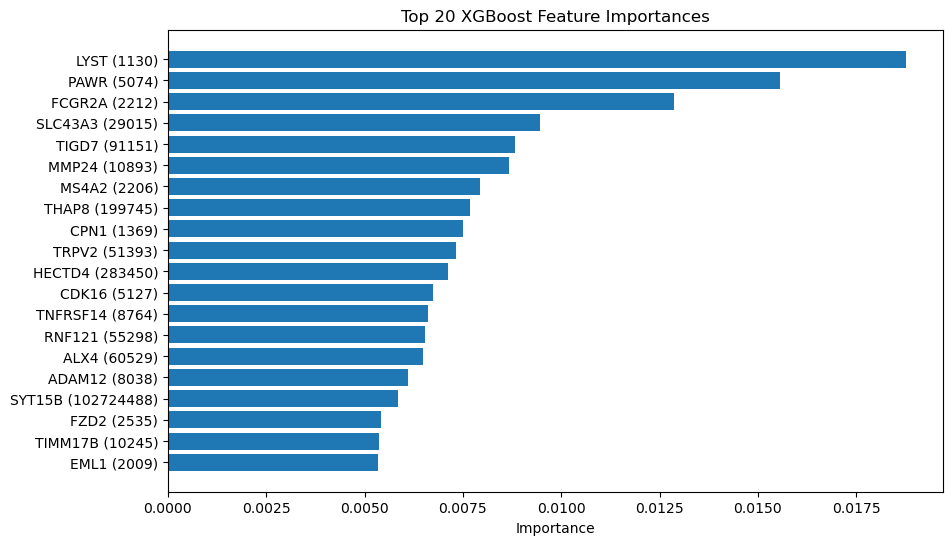

In [12]:
top_features = feature_importance.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Gene"][::-1], top_features["Importance"][::-1])
plt.xlabel("Importance")
plt.title("Top 20 XGBoost Feature Importances")
plt.show()

## Evaluation Summary

The tuned XGBoost model achieved the best overall performance, with an RMSE of 0.883 and an R² of 0.537. This means the model explained about 54% of the variance in AZ-628 response using gene expression features.

The nonlinear models outperformed the Ridge baseline, suggesting that drug response is influenced by nonlinear relationships and interactions between genes. Hyperparameter tuning slightly improved performance, especially for XGBoost.

The feature importance analysis identified genes that contributed most strongly to prediction.